In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train_path = "../data/raw/UNSW-NB15/UNSW_NB15_training-set.csv"
test_path = "../data/raw/UNSW-NB15/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/UNSW-NB15/UNSW_NB15_training-set.csv'

In [5]:
import os

print(os.getcwd())

C:\Users\83GS008BIN\OneDrive\Desktop\Nexora\Nexora\notebooks


In [6]:
print(os.listdir())

['.ipynb_checkpoints', 'week1_eda.ipynb', 'week2_unsw_eda.ipynb']


In [7]:
import os

path = "../data/raw/UNSW-NB15"

print("Folder exists:", os.path.exists(path))
print("Files:", os.listdir(path) if os.path.exists(path) else "Folder not found")

Folder exists: True
Files: ['UNSW_NB15_testing-set.csv']


In [8]:
import os

print(os.listdir("../data/raw/UNSW-NB15"))

['UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']


In [9]:
train_path = "../data/raw/UNSW-NB15/UNSW_NB15_training-set.csv"
test_path = "../data/raw/UNSW-NB15/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (175341, 45)
Testing shape: (82332, 45)


In [10]:
print("Columns:")
for i, col in enumerate(train_df.columns):
    print(i, ":", col)

Columns:
0 : id
1 : dur
2 : proto
3 : service
4 : state
5 : spkts
6 : dpkts
7 : sbytes
8 : dbytes
9 : rate
10 : sttl
11 : dttl
12 : sload
13 : dload
14 : sloss
15 : dloss
16 : sinpkt
17 : dinpkt
18 : sjit
19 : djit
20 : swin
21 : stcpb
22 : dtcpb
23 : dwin
24 : tcprtt
25 : synack
26 : ackdat
27 : smean
28 : dmean
29 : trans_depth
30 : response_body_len
31 : ct_srv_src
32 : ct_state_ttl
33 : ct_dst_ltm
34 : ct_src_dport_ltm
35 : ct_dst_sport_ltm
36 : ct_dst_src_ltm
37 : is_ftp_login
38 : ct_ftp_cmd
39 : ct_flw_http_mthd
40 : ct_src_ltm
41 : ct_srv_dst
42 : is_sm_ips_ports
43 : attack_cat
44 : label


In [11]:
print("\nData types:")
print(train_df.dtypes)


Data types:
id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
c

In [12]:
print("\nFirst 5 rows:")
display(train_df.head())


First 5 rows:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [13]:
print(train_df.columns[-5:])

Index(['ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label'], dtype='str')


In [14]:
print("\nattack_cat values:")
print(train_df["attack_cat"].value_counts(dropna=False))


attack_cat values:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


In [15]:
print("\nlabel values:")
print(train_df["label"].value_counts(dropna=False))


label values:
label
1    119341
0     56000
Name: count, dtype: int64


In [16]:
missing = train_df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
Series([], dtype: int64)


In [17]:
print("Total missing values:", train_df.isnull().sum().sum())

Total missing values: 0


In [18]:
duplicates = train_df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [19]:
duplicate_percent = (duplicates / len(train_df)) * 100

print("Duplicate percentage:", duplicate_percent, "%")

Duplicate percentage: 0.0 %


In [20]:
numeric_cols = train_df.select_dtypes(include=np.number).columns

inf_count = np.isinf(train_df[numeric_cols]).sum().sum()

print("Total infinite values:", inf_count)

Total infinite values: 0


In [21]:
numeric_count = train_df.select_dtypes(include=np.number).shape[1]
non_numeric_count = train_df.select_dtypes(exclude=np.number).shape[1]

print("Numerical columns:", numeric_count)
print("Non-numerical columns:", non_numeric_count)

Numerical columns: 41
Non-numerical columns: 4


In [22]:
categorical_cols = train_df.select_dtypes(exclude=np.number).columns

print("Non-numerical columns:")
for col in categorical_cols:
    print("-", col)

Non-numerical columns:
- proto
- service
- state
- attack_cat


In [23]:
print("\nUnique values:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(train_df[col].unique())


Unique values:

proto:
<StringArray>
[      'tcp',       'udp',       'arp',      'ospf',      'icmp',      'igmp',
       'rtp',       'ddp', 'ipv6-frag',      'cftp',
 ...
   'trunk-1',   'xns-idp',    'leaf-1',    'leaf-2',       'rdp',      'irtp',
   'iso-tp4',    'netblt',   'trunk-2',       'cbt']
Length: 133, dtype: str

service:
<StringArray>
[       '-',      'ftp',     'smtp',     'snmp',     'http', 'ftp-data',
      'dns',      'ssh',   'radius',     'pop3',     'dhcp',      'ssl',
      'irc']
Length: 13, dtype: str

state:
<StringArray>
['FIN', 'INT', 'CON', 'ECO', 'REQ', 'RST', 'PAR', 'URN', 'no']
Length: 9, dtype: str

attack_cat:
<StringArray>
[        'Normal',       'Backdoor',       'Analysis',        'Fuzzers',
      'Shellcode', 'Reconnaissance',       'Exploits',            'DoS',
          'Worms',        'Generic']
Length: 10, dtype: str


label
0     56000
1    119341
Name: count, dtype: int64


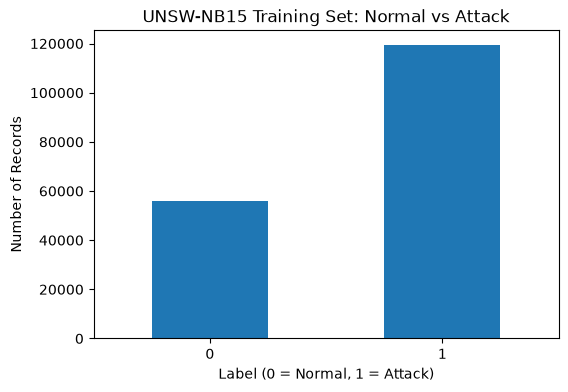

In [24]:
label_counts = train_df["label"].value_counts().sort_index()

print(label_counts)

plt.figure(figsize=(6, 4))
label_counts.plot(kind="bar")
plt.title("UNSW-NB15 Training Set: Normal vs Attack")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [25]:
label_percent = train_df["label"].value_counts(normalize=True).sort_index() * 100

print("Label distribution (%):")
print(label_percent)

Label distribution (%):
label
0    31.937767
1    68.062233
Name: proportion, dtype: float64


In [26]:
|print(f"Normal: {label_percent[0]:.2f}%")
print(f"Attack: {label_percent[1]:.2f}%")

SyntaxError: invalid syntax (2092557296.py, line 1)

In [27]:
print(f"Normal: {label_percent[0]:.2f}%")
print(f"Attack: {label_percent[1]:.2f}%")

Normal: 31.94%
Attack: 68.06%


In [28]:
attack_counts = train_df["attack_cat"].value_counts()

print("Attack category distribution:")
print(attack_counts)

Attack category distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


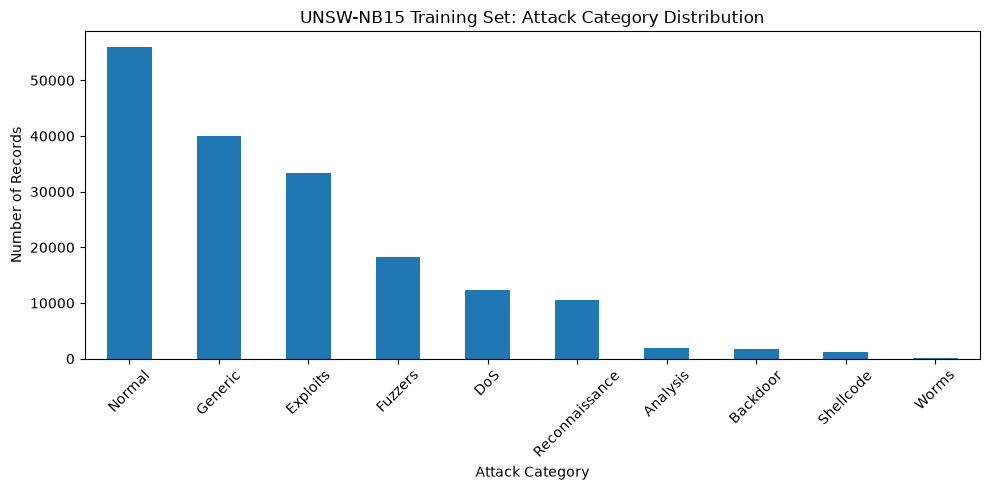

In [29]:
plt.figure(figsize=(10, 5))
attack_counts.plot(kind="bar")
plt.title("UNSW-NB15 Training Set: Attack Category Distribution")
plt.xlabel("Attack Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,175341.0,8.767100e+04,5.061673e+04,1.0,43836.000000,87671.000000,1.315060e+05,1.753410e+05
dur,175341.0,1.359389e+00,6.480249e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540619e+04,1.654010e+05,0.0,32.786140,3225.806520,1.250000e+05,1.000000e+06
sttl,175341.0,1.795470e+02,1.029400e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,175341.0,7.960957e+01,1.105069e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.338870,879674.750000,8.888889e+07,5.988000e+09


In [31]:
print(train_df.describe().T[["mean", "std", "min", "max"]])

                           mean           std   min           max
id                 8.767100e+04  5.061673e+04   1.0  1.753410e+05
dur                1.359389e+00  6.480249e+00   0.0  5.999999e+01
spkts              2.029866e+01  1.368876e+02   1.0  9.616000e+03
dpkts              1.896959e+01  1.102583e+02   0.0  1.097400e+04
sbytes             8.844844e+03  1.747656e+05  28.0  1.296523e+07
dbytes             1.492892e+04  1.436542e+05   0.0  1.465555e+07
rate               9.540619e+04  1.654010e+05   0.0  1.000000e+06
sttl               1.795470e+02  1.029400e+02   0.0  2.550000e+02
dttl               7.960957e+01  1.105069e+02   0.0  2.540000e+02
sload              7.345403e+07  1.883574e+08   0.0  5.988000e+09
dload              6.712056e+05  2.421312e+06   0.0  2.242273e+07
sloss              4.953000e+00  6.600506e+01   0.0  4.803000e+03
dloss              6.948010e+00  5.273300e+01   0.0  5.484000e+03
sinpkt             9.859769e+02  7.242246e+03   0.0  8.437150e+04
dinpkt    

In [32]:
skewness = train_df[numeric_cols].skew().sort_values(ascending=False)

print("Most positively skewed features:")
print(skewness.head(10))

Most positively skewed features:
trans_depth          167.335829
response_body_len     76.340075
sbytes                45.303443
sloss                 44.753662
dloss                 41.380270
spkts                 40.217703
dbytes                39.760864
dpkts                 36.764114
dinpkt                29.679512
djit                  29.543830
dtype: float64


In [33]:
print("\nMost negatively skewed features:")
print(skewness.tail(10))


Most negatively skewed features:
ct_srv_src      1.521178
stcpb           1.081121
dtcpb           1.081017
ct_state_ttl    0.928414
dttl            0.895010
dwin            0.196820
swin            0.177048
id              0.000000
sttl           -0.678109
label          -0.774818
dtype: float64


In [34]:
Q1 = train_df[numeric_cols].quantile(0.25)
Q3 = train_df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((train_df[numeric_cols] < lower) |
                  (train_df[numeric_cols] > upper)).sum()

outlier_counts = outlier_counts.sort_values(ascending=False)

print("Top 15 features by IQR outlier count:")
print(outlier_counts.head(15))

Top 15 features by IQR outlier count:
dload               38143
ct_dst_sport_ltm    37337
ct_src_dport_ltm    33423
synack              31462
dloss               28388
dbytes              28131
spkts               24675
dmean               23359
sbytes              22873
ct_dst_ltm          22152
dpkts               20830
smean               20725
djit                20574
ct_srv_src          19390
ct_srv_dst          19341
dtype: int64


In [35]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nSame columns:", list(train_df.columns) == list(test_df.columns))

print("\nTraining labels:")
print(train_df["label"].value_counts())

print("\nTesting labels:")
print(test_df["label"].value_counts())

Training shape: (175341, 45)
Testing shape: (82332, 45)

Same columns: True

Training labels:
label
1    119341
0     56000
Name: count, dtype: int64

Testing labels:
label
1    45332
0    37000
Name: count, dtype: int64


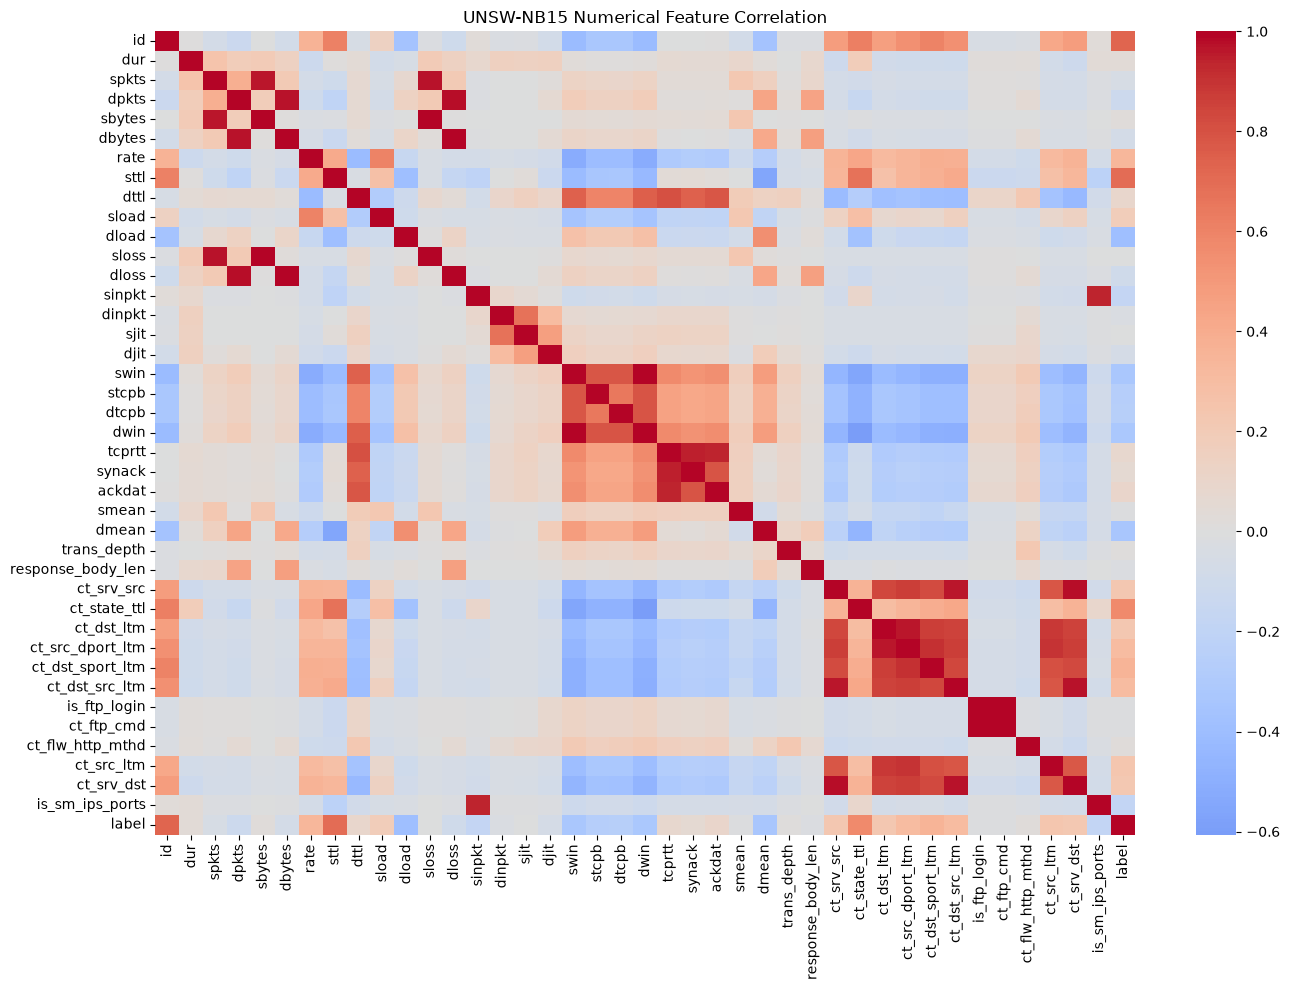

In [36]:
corr = train_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("UNSW-NB15 Numerical Feature Correlation")
plt.tight_layout()
plt.show()

In [37]:
corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

print("Top 15 positive correlations:")
print(corr_pairs.head(15))

Top 15 positive correlations:
is_ftp_login    ct_ftp_cmd          1.000000
dbytes          dloss               0.996504
sbytes          sloss               0.996109
swin            dwin                0.990140
ct_srv_src      ct_srv_dst          0.980323
dpkts           dloss               0.978636
ct_dst_src_ltm  ct_srv_dst          0.972370
dpkts           dbytes              0.971907
spkts           sloss               0.971069
ct_srv_src      ct_dst_src_ltm      0.967138
spkts           sbytes              0.963791
ct_dst_ltm      ct_src_dport_ltm    0.962052
tcprtt          synack              0.949468
                ackdat              0.941760
sinpkt          is_sm_ips_ports     0.941319
dtype: float64


In [38]:
print("\nTop 15 negative correlations:")
print(corr_pairs.tail(15))


Top 15 negative correlations:
label  trans_depth         NaN
       response_body_len   NaN
       ct_srv_src          NaN
       ct_state_ttl        NaN
       ct_dst_ltm          NaN
       ct_src_dport_ltm    NaN
       ct_dst_sport_ltm    NaN
       ct_dst_src_ltm      NaN
       is_ftp_login        NaN
       ct_ftp_cmd          NaN
       ct_flw_http_mthd    NaN
       ct_src_ltm          NaN
       ct_srv_dst          NaN
       is_sm_ips_ports     NaN
       label               NaN
dtype: float64


In [39]:
# Exclude target columns from feature correlation analysis
feature_cols = [col for col in numeric_cols if col not in ["label"]]

feature_corr = train_df[feature_cols].corr()

# Get pairs with absolute correlation >= 0.8
corr_pairs = (
    feature_corr.where(
        np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Highly correlated feature pairs (|correlation| >= 0.8):")
print(corr_pairs[abs(corr_pairs) >= 0.8].head(30))

Highly correlated feature pairs (|correlation| >= 0.8):
is_ftp_login      ct_ftp_cmd          1.000000
dbytes            dloss               0.996504
sbytes            sloss               0.996109
swin              dwin                0.990140
ct_srv_src        ct_srv_dst          0.980323
dpkts             dloss               0.978636
ct_dst_src_ltm    ct_srv_dst          0.972370
dpkts             dbytes              0.971907
spkts             sloss               0.971069
ct_srv_src        ct_dst_src_ltm      0.967138
spkts             sbytes              0.963791
ct_dst_ltm        ct_src_dport_ltm    0.962052
tcprtt            synack              0.949468
                  ackdat              0.941760
sinpkt            is_sm_ips_ports     0.941319
ct_src_dport_ltm  ct_dst_sport_ltm    0.906793
                  ct_src_ltm          0.897438
ct_dst_ltm        ct_src_ltm          0.886072
                  ct_dst_sport_ltm    0.870644
ct_src_dport_ltm  ct_dst_src_ltm      0.869941
    

In [40]:
# Separate targets from features

X = train_df.drop(columns=["label", "attack_cat"])
y = train_df["label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (175341, 43)
Target shape: (175341,)

Features:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [41]:
categorical_features = ["proto", "service", "state"]

for col in categorical_features:
    print(f"\n{col}:")
    print(X[col].value_counts().head(15))


proto:
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
swipe       201
mobile      201
pim         201
ipv6        201
rsvp        200
sep         193
Name: count, dtype: int64

service:
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

state:
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


In [42]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded = encoder.fit_transform(X[categorical_features])

print("Original categorical columns:", len(categorical_features))
print("Encoded categorical columns:", encoded.shape[1])

Original categorical columns: 3
Encoded categorical columns: 155


In [43]:
from sklearn.preprocessing import StandardScaler

numeric_features = X.select_dtypes(include=np.number).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total after encoding:", len(numeric_features) + encoded.shape[1])

Numerical features: 40
Categorical features: 3
Total after encoding: 195


In [44]:
# Convert encoded categorical data into a DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X.index
)

# Keep numerical features
numeric_df = X[numeric_features].copy()

# Combine numerical + encoded categorical features
X_processed = pd.concat([numeric_df, encoded_df], axis=1)

print("Processed feature shape:", X_processed.shape)
print("Target shape:", y.shape)

Processed feature shape: (175341, 195)
Target shape: (175341,)


In [45]:
print("\nNon-numerical columns:",
      X_processed.select_dtypes(exclude=np.number).shape[1])

print("Missing values:", X_processed.isnull().sum().sum())


Non-numerical columns: 0
Missing values: 0


In [46]:
scaler = StandardScaler()

X_scaled = X_processed.copy()

X_scaled[numeric_features] = scaler.fit_transform(
    X_processed[numeric_features]
)

print("Scaled feature shape:", X_scaled.shape)
print("\nMean of first 5 numerical features:")
print(X_scaled[numeric_features[:5]].mean())

print("\nStd of first 5 numerical features:")
print(X_scaled[numeric_features[:5]].std())

Scaled feature shape: (175341, 195)

Mean of first 5 numerical features:
id       -8.299209e-17
dur      -7.780508e-18
spkts    -1.037401e-17
dpkts     0.000000e+00
sbytes   -3.890254e-18
dtype: float64

Std of first 5 numerical features:
id        1.000003
dur       1.000003
spkts     1.000003
dpkts     1.000003
sbytes    1.000003
dtype: float64


In [47]:
# Separate test features and target
X_test = test_df.drop(columns=["label", "attack_cat"])
y_test = test_df["label"]

# Encode categorical features using the already-fitted encoder
test_encoded = encoder.transform(X_test[categorical_features])

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoder.get_feature_names_out(categorical_features),
    index=X_test.index
)

# Numerical features
test_numeric_df = X_test[numeric_features].copy()

# Combine
X_test_processed = pd.concat(
    [test_numeric_df, test_encoded_df],
    axis=1
)

# Scale using the already-fitted scaler
X_test_scaled = X_test_processed.copy()

X_test_scaled[numeric_features] = scaler.transform(
    X_test_processed[numeric_features]
)

print("Processed test shape:", X_test_scaled.shape)
print("Test target shape:", y_test.shape)

Processed test shape: (82332, 195)
Test target shape: (82332,)


In [48]:
print("Test missing values:", X_test_scaled.isnull().sum().sum())
print("Test non-numerical columns:",
      X_test_scaled.select_dtypes(exclude=np.number).shape[1])

Test missing values: 0
Test non-numerical columns: 0


## Preprocessing Summary

- Removed `label` and `attack_cat` from the feature matrix.
- Separated numerical and categorical features.
- Categorical features:
  - `proto`
  - `service`
  - `state`
- Applied One-Hot Encoding to categorical features using `handle_unknown="ignore"`.
- Scaled numerical features using `StandardScaler`.
- The scaler was fitted only on the training data.
- The same encoder and scaler were applied to the testing data.
- Final feature representation contains 195 features.
- Training set: 175,341 samples.
- Testing set: 82,332 samples.
- No missing values or infinite values were introduced during preprocessing.

In [50]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

print("Isolation Forest imported successfully")

Isolation Forest imported successfully


In [51]:
# Create a stratified subset for the first prototype
from sklearn.model_selection import train_test_split

X_iforest, _, y_iforest, _ = train_test_split(
    X_scaled,
    y,
    train_size=50000,
    stratify=y,
    random_state=42
)

print("Isolation Forest subset:", X_iforest.shape)
print("\nSubset label distribution:")
print(y_iforest.value_counts())

Isolation Forest subset: (50000, 195)

Subset label distribution:
label
1    34031
0    15969
Name: count, dtype: int64


In [52]:
# Train the first Isolation Forest baseline

iso_forest = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_iforest)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [53]:
# Generate Isolation Forest predictions

iforest_raw_pred = iso_forest.predict(X_iforest)

# Convert:
# Isolation Forest:  1 = normal, -1 = anomaly
# Dataset label:     0 = normal, 1 = attack

iforest_pred = np.where(iforest_raw_pred == -1, 1, 0)

print("Prediction counts:")
print(pd.Series(iforest_pred).value_counts().sort_index())

Prediction counts:
0    49486
1      514
Name: count, dtype: int64


In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_iforest, iforest_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15675   294]
 [33811   220]]


In [55]:
print("\nActual label distribution:")
print(y_iforest.value_counts().sort_index())

print("\nPredicted label distribution:")
print(pd.Series(iforest_pred).value_counts().sort_index())


Actual label distribution:
label
0    15969
1    34031
Name: count, dtype: int64

Predicted label distribution:
0    49486
1      514
Name: count, dtype: int64


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_iforest, iforest_pred)
recall = recall_score(y_iforest, iforest_pred)
f1 = f1_score(y_iforest, iforest_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Precision: 0.4280
Recall:    0.0065
F1 Score:  0.0127


In [57]:
print("\nClassification Report:")
print(classification_report(
    y_iforest,
    iforest_pred,
    target_names=["Normal", "Attack"]
))


Classification Report:
              precision    recall  f1-score   support

      Normal       0.32      0.98      0.48     15969
      Attack       0.43      0.01      0.01     34031

    accuracy                           0.32     50000
   macro avg       0.37      0.49      0.25     50000
weighted avg       0.39      0.32      0.16     50000



In [58]:
iso_forest_10 = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

iso_forest_10.fit(X_iforest)

pred_raw_10 = iso_forest_10.predict(X_iforest)

pred_10 = np.where(pred_raw_10 == -1, 1, 0)

print("Prediction distribution:")
print(pd.Series(pred_10).value_counts().sort_index())

Prediction distribution:
0    45000
1     5000
Name: count, dtype: int64


In [59]:
print("\nClassification Report - 10% contamination:")
print(classification_report(
    y_iforest,
    pred_10,
    target_names=["Normal", "Attack"]
))


Classification Report - 10% contamination:
              precision    recall  f1-score   support

      Normal       0.31      0.88      0.46     15969
      Attack       0.61      0.09      0.16     34031

    accuracy                           0.34     50000
   macro avg       0.46      0.48      0.31     50000
weighted avg       0.52      0.34      0.25     50000



In [60]:
print("Confusion Matrix:")
print(confusion_matrix(y_iforest, pred_10))

Confusion Matrix:
[[14038  1931]
 [30962  3069]]


In [61]:
comparison = pd.DataFrame({
    "Model": [
        "Isolation Forest (auto)",
        "Isolation Forest (10% contamination)"
    ],
    "Precision": [
        precision_score(y_iforest, iforest_pred),
        precision_score(y_iforest, pred_10)
    ],
    "Recall": [
        recall_score(y_iforest, iforest_pred),
        recall_score(y_iforest, pred_10)
    ],
    "F1 Score": [
        f1_score(y_iforest, iforest_pred),
        f1_score(y_iforest, pred_10)
    ]
})

print(comparison.round(4))

                                  Model  Precision  Recall  F1 Score
0               Isolation Forest (auto)     0.4280  0.0065    0.0127
1  Isolation Forest (10% contamination)     0.6138  0.0902    0.1573
